# HTLML Hybrid

In [5]:
# --- Kaggle: ADNI via gdown ---
import os, subprocess
from pathlib import Path
GDRIVE_FILE_ID = '1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz'
WORK_DIR = Path('/kaggle/working')
ADNI_ZIP_PATH = WORK_DIR / 'adni_dataset.zip'
if not os.path.exists(WORK_DIR / 'CN'):
    subprocess.run(['pip', 'install', '-q', 'gdown'], check=True)
    import gdown
    gdown.download(f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}', str(ADNI_ZIP_PATH), quiet=False)
    import zipfile
    with zipfile.ZipFile(str(ADNI_ZIP_PATH), 'r') as zf:
        zf.extractall(str(WORK_DIR))
    ADNI_ZIP_PATH.unlink(missing_ok=True)
ADNI_DIR = str(WORK_DIR)
for root, dirs, files in os.walk(WORK_DIR):
    if 'CN' in dirs and 'MCI' in dirs and 'AD' in dirs:
        ADNI_DIR = root
        break
print(f'ADNI_DIR = {ADNI_DIR}')

Downloading...
From (original): https://drive.google.com/uc?id=1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz
From (redirected): https://drive.google.com/uc?id=1uc4Nb_z6_q5DzqYfN9EtRagtstkPf2rz&confirm=t&uuid=7185bcdb-d252-4c55-86c0-407ae79dbc2e
To: /kaggle/working/adni_dataset.zip
100%|██████████| 387M/387M [00:03<00:00, 103MB/s]  


ADNI_DIR = /kaggle/working/adni_nifti_preprocessed


In [6]:
%pip install -q xgboost captum lime scikit-image shap

Note: you may need to restart the kernel to use updated packages.


In [7]:
import csv
import json
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import inception_v3, Inception_V3_Weights, vgg16, VGG16_Weights
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report, log_loss, precision_recall_fscore_support
from sklearn.base import clone
from xgboost import XGBClassifier
import joblib
import torch._dynamo
torch._dynamo.config.suppress_errors = True
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [8]:
# --- Config (Phase2-style + small-data) ---
DATA_ROOT = ADNI_DIR
TRAIN_RATIO = 0.80
IMAGE_SIZE = 299
PREPROCESS_MODE = 'gray3'
OUTPUT_DIR = f'/kaggle/working/preprocessed_htlml_mc_299_{PREPROCESS_MODE}'
CKPT_DIR = '/kaggle/working/checkpoints_htlml_multiclass'
os.makedirs(CKPT_DIR, exist_ok=True)
FEAT_BATCH = 32
BATCH_SIZE = 16
USE_PCA = False
PCA_DIM = 128
EVAL_MODE = 'single_split'
SKFOLDS = 5
XGB_N_ESTIMATORS = 120
XGB_MAX_DEPTH = 3
LIME_NUM_SAMPLES = 100
GRADCAM_BRANCH = 'inception'
SHAP_BG_SAMPLES = 12
NUM_EPOCHS_HEAD = 30
LR_HEAD = 1e-3
PATIENCE_HEAD = 8
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
CLASS_NAMES = sorted([d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d)) and d in ('AD','CN','MCI')])
if not CLASS_NAMES:
    CLASS_NAMES = sorted([d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))])
print(f'Classes: {CLASS_NAMES} | PREPROCESS_MODE={PREPROCESS_MODE} | EVAL_MODE={EVAL_MODE}')

Classes: ['AD', 'CN', 'MCI'] | PREPROCESS_MODE=gray3 | EVAL_MODE=single_split


In [9]:
all_paths, all_labels = [], []
for idx, cls in enumerate(CLASS_NAMES):
    cls_root = os.path.join(DATA_ROOT, cls)
    if not os.path.isdir(cls_root):
        continue
    for dirpath, _, fnames in os.walk(cls_root):
        for fname in fnames:
            if os.path.splitext(fname)[1].lower() in VALID_EXTS:
                all_paths.append(os.path.join(dirpath, fname))
                all_labels.append(idx)
print(f'Total slices: {len(all_paths)}')
for i, c in enumerate(CLASS_NAMES):
    print(f'  {c}: {all_labels.count(i)}')

Total slices: 8512
  AD: 1434
  CN: 2341
  MCI: 4737


In [10]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=1 - TRAIN_RATIO, stratify=all_labels, random_state=SEED)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=SEED)
print(f'Train {len(train_paths)} | Val {len(val_paths)} | Test {len(test_paths)}')

Train 6809 | Val 851 | Test 852


In [11]:
tr, va, te = set(train_paths), set(val_paths), set(test_paths)
print(f'Overlap train-val {len(tr&va)} train-test {len(tr&te)} val-test {len(va&te)}')
assert not (tr & va) and not (tr & te) and not (va & te)
print('Class distribution:')
for name, lbls in [('train', train_labels), ('val', val_labels), ('test', test_labels)]:
    print(f'  {name}: {dict(sorted(Counter(lbls).items()))}')

Overlap train-val 0 train-test 0 val-test 0
Class distribution:
  train: {0: 1147, 1: 1873, 2: 3789}
  val: {0: 143, 1: 234, 2: 474}
  test: {0: 144, 1: 234, 2: 474}


In [12]:
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)
filename_usage = {}

def save_tensors(paths, labels, split_name):
    split_dir = os.path.join(OUTPUT_DIR, split_name)
    for path, label in tqdm(zip(paths, labels), total=len(paths), desc=f'Save {split_name}'):
        cls_name = CLASS_NAMES[label]
        out_dir = os.path.join(split_dir, cls_name)
        os.makedirs(out_dir, exist_ok=True)
        base = os.path.splitext(os.path.basename(path))[0]
        parent = os.path.basename(os.path.dirname(path))
        tracking_key = f'{cls_name}_{parent}_{base}'
        if tracking_key in filename_usage:
            filename_usage[tracking_key] += 1
            unique = f'{parent}_{base}_dup{filename_usage[tracking_key]}.pt'
        else:
            filename_usage[tracking_key] = 0
            unique = f'{parent}_{base}.pt'
        out_path = os.path.join(out_dir, unique)
        if os.path.exists(out_path):
            continue
        if PREPROCESS_MODE == 'rgb':
            img = Image.open(path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
            t = (transforms.ToTensor()(img) * 255).byte()
        elif PREPROCESS_MODE == 'gray3':
            img = Image.open(path).convert('L').resize((IMAGE_SIZE, IMAGE_SIZE))
            t = (transforms.ToTensor()(img) * 255).byte().repeat(3, 1, 1)
        else:
            raise ValueError('PREPROCESS_MODE')
        torch.save(t, out_path)

save_tensors(train_paths, train_labels, 'train')
save_tensors(val_paths, val_labels, 'val')
save_tensors(test_paths, test_labels, 'test')
print('Cache done.')

Save test: 100%|██████████| 852/852 [00:02<00:00, 315.89it/s]

Cache done.


In [13]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
train_augment = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
])

class AlzheimerDataset(Dataset):
    def __init__(self, split_dir, class_names, augment=False):
        self.samples, self.augment = [], augment
        for idx, cls in enumerate(class_names):
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.endswith('.pt'):
                    self.samples.append((os.path.join(cls_dir, fname), idx))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        pth, lab = self.samples[i]
        t = torch.load(pth, weights_only=True).float() / 255.0
        if self.augment:
            t = train_augment(t)
        return normalize(t), lab
    def get_labels(self):
        return [s[1] for s in self.samples]

train_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, 'train'), CLASS_NAMES, augment=True)
val_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, 'val'), CLASS_NAMES)
test_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, 'test'), CLASS_NAMES)
print(f'Datasets: train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}')
train_labels_list = train_ds.get_labels()
cc = Counter(train_labels_list)
wts = [1.0 / cc[l] for l in train_labels_list]
sampler = WeightedRandomSampler(wts, len(wts), replacement=True)
nw = min(4, os.cpu_count() or 1)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=nw, pin_memory=True, persistent_workers=nw>0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=nw, pin_memory=True, persistent_workers=nw>0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=nw, pin_memory=True, persistent_workers=nw>0)
feat_train_loader = DataLoader(train_ds, batch_size=FEAT_BATCH, shuffle=False, num_workers=nw, pin_memory=True, persistent_workers=nw>0)
feat_val_loader = DataLoader(val_ds, batch_size=FEAT_BATCH, shuffle=False, num_workers=nw, pin_memory=True, persistent_workers=nw>0)
feat_test_loader = DataLoader(test_ds, batch_size=FEAT_BATCH, shuffle=False, num_workers=nw, pin_memory=True, persistent_workers=nw>0)

Datasets: train=6809 val=851 test=852


In [14]:
class InceptionVGGFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        inc = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1, transform_input=False)
        inc.aux_logits = False
        inc.fc = nn.Identity()
        self.inception = inc
        vgg = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
        self.vgg_features = vgg.features
        self.vgg_pool = nn.AdaptiveAvgPool2d((1, 1))
        for p in self.parameters():
            p.requires_grad = False
    def forward(self, x):
        return torch.cat([self.inception(x), torch.flatten(self.vgg_pool(self.vgg_features(x)), 1)], dim=1)

def extract_features_matrix(loader, fe):
    fe.eval()
    xs, ys = [], []
    dev = next(fe.parameters()).device
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Feats', leave=False):
            images = images.to(dev, non_blocking=True)
            with torch.amp.autocast(device_type='cuda' if dev.type == 'cuda' else 'cpu', enabled=dev.type=='cuda'):
                z = fe(images)
            xs.append(z.float().cpu().numpy())
            ys.append(labels.numpy())
    if not xs:
        return np.zeros((0, 2560), np.float32), np.zeros((0,), np.int64)
    return np.concatenate(xs, 0), np.concatenate(ys, 0)

fe = InceptionVGGFeatureExtractor().to(device).eval()
print('Extractor ready (2560-D).')

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 181MB/s] 


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 190MB/s]  


Extractor ready (2560-D).


In [15]:
def build_multiclass_htlml_pipeline():
    K = len(CLASS_NAMES)
    svm = SVC(kernel='linear', C=0.5, probability=True, class_weight='balanced', random_state=SEED)
    gnb = GaussianNB()
    xgb = XGBClassifier(
        objective='multi:softprob', num_class=K, n_estimators=XGB_N_ESTIMATORS, max_depth=XGB_MAX_DEPTH,
        learning_rate=0.06, subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0, min_child_weight=2,
        random_state=SEED, n_jobs=-1, tree_method='hist', eval_metric='mlogloss',
    )
    vote = VotingClassifier(estimators=[('svm', svm), ('gnb', gnb), ('xgb', xgb)], voting='soft')
    steps = []
    if USE_PCA:
        steps.append(('pca', PCA(n_components=PCA_DIM, random_state=SEED)))
    steps.append(('scaler', StandardScaler()))
    steps.append(('vote', vote))
    return Pipeline(steps)

print('Extracting train/val/test features...')
X_train, y_train = extract_features_matrix(feat_train_loader, fe)
X_val, y_val = extract_features_matrix(feat_val_loader, fe)
X_test, y_test = extract_features_matrix(feat_test_loader, fe)
print(X_train.shape, X_val.shape, X_test.shape)

ml_pipe = build_multiclass_htlml_pipeline()
if EVAL_MODE == 'skfold_inner' and len(y_train) >= SKFOLDS * 3:
    skf = StratifiedKFold(n_splits=SKFOLDS, shuffle=True, random_state=SEED)
    lls = []
    for tr_idx, va_idx in skf.split(X_train, y_train):
        p = clone(ml_pipe)
        p.fit(X_train[tr_idx], y_train[tr_idx])
        prob = p.predict_proba(X_train[va_idx])
        try:
            lls.append(log_loss(y_train[va_idx], prob, labels=list(range(len(CLASS_NAMES)))))
        except ValueError:
            lls.append(float('nan'))
    print(f'Inner CV train log_loss: {float(np.mean(lls)):.4f} +/- {float(np.std(lls)):.4f}')
ml_pipe.fit(X_train, y_train)
val_prob = ml_pipe.predict_proba(X_val)
test_prob = ml_pipe.predict_proba(X_test)
for name, y, pr in [('train', y_train, ml_pipe.predict_proba(X_train)), ('val', y_val, val_prob), ('test', y_test, test_prob)]:
    try:
        ll = log_loss(y, pr, labels=list(range(len(CLASS_NAMES))))
    except Exception as e:
        ll = float('nan')
    pred = pr.argmax(1)
    acc = float(np.mean(pred == y))
    print(f'{name}: log_loss={ll:.4f} slice_acc={acc*100:.2f}%')
joblib.dump(ml_pipe, os.path.join(CKPT_DIR, 'htlml_multiclass_sklearn.joblib'))
print('Saved sklearn pipeline.')

Extracting train/val/test features...


(6809, 2560) (851, 2560) (852, 2560)
train: log_loss=0.6116 slice_acc=68.12%
val: log_loss=0.7609 slice_acc=61.81%
test: log_loss=0.7628 slice_acc=62.56%
Saved sklearn pipeline.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


              precision    recall  f1-score   support

          AD     0.4412    0.5208    0.4777       144
          CN     0.5356    0.5470    0.5412       234
         MCI     0.7449    0.6962    0.7197       474

    accuracy                         0.6256       852
   macro avg     0.5739    0.5880    0.5796       852
weighted avg     0.6361    0.6256    0.6298       852

Per-class test:
  AD: P=0.441 R=0.521 F1=0.478 n=144
  CN: P=0.536 R=0.547 F1=0.541 n=234
  MCI: P=0.745 R=0.696 F1=0.720 n=474


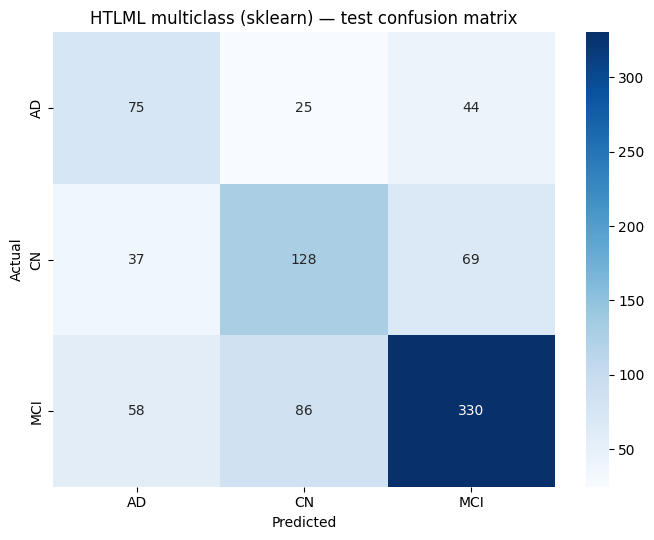

In [16]:
pred_test = test_prob.argmax(1)
print(classification_report(y_test, pred_test, target_names=CLASS_NAMES, digits=4))
prec, rec, f1, sup = precision_recall_fscore_support(y_test, pred_test, average=None, zero_division=0)
print('Per-class test:')
for i, c in enumerate(CLASS_NAMES):
    print(f'  {c}: P={prec[i]:.3f} R={rec[i]:.3f} F1={f1[i]:.3f} n={sup[i]}')
cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.title('HTLML multiclass (sklearn) — test confusion matrix')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'cm_htlml_multiclass_sklearn.png'), dpi=150)
plt.show()

In [17]:
class HTLMLImageClassifier(nn.Module):
    def __init__(self, backbone_fe, n_cls):
        super().__init__()
        self.fe = backbone_fe
        self.fc = nn.Linear(2560, n_cls)
    def forward(self, x):
        return self.fc(self.fe(x))

sur = HTLMLImageClassifier(fe, len(CLASS_NAMES)).to(device)
for p in sur.fe.parameters():
    p.requires_grad = False
crit = nn.CrossEntropyLoss()
opt = optim.AdamW(sur.fc.parameters(), lr=LR_HEAD, weight_decay=1e-4)
scaler = torch.amp.GradScaler(enabled=device.type == 'cuda')

def run_epoch(loader, train_mode):
    if train_mode:
        sur.train(); sur.fe.eval()
    else:
        sur.eval()
    tot_loss = tot = corr = 0
    ctx = torch.enable_grad() if train_mode else torch.no_grad()
    with ctx:
        for x, y in tqdm(loader, desc='tr' if train_mode else 'va', leave=False):
            x, y = x.to(device), y.to(device)
            with torch.amp.autocast(device_type='cuda', enabled=device.type == 'cuda'):
                logits = sur(x)
                loss = crit(logits, y)
            if train_mode:
                opt.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            tot_loss += loss.item() * y.size(0)
            tot += y.size(0)
            corr += (logits.argmax(1) == y).sum().item()
    return tot_loss / max(tot, 1), corr / max(tot, 1)

best, bad = float('inf'), 0
for ep in range(1, NUM_EPOCHS_HEAD + 1):
    tl, ta = run_epoch(train_loader, True)
    vl, va = run_epoch(val_loader, False)
    print(f'Head ep{ep:02d} train_loss={tl:.4f} acc={ta*100:.1f}% | val_loss={vl:.4f} acc={va*100:.1f}%')
    if vl < best - 1e-5:
        best, bad = vl, 0
        torch.save(sur.state_dict(), os.path.join(CKPT_DIR, 'htlml_multiclass_torch_head.pt'))
    else:
        bad += 1
        if bad >= PATIENCE_HEAD:
            break
sur.load_state_dict(torch.load(os.path.join(CKPT_DIR, 'htlml_multiclass_torch_head.pt'), map_location=device))
sur.eval()
print('Torch head trained.')

Head ep01 train_loss=0.9987 acc=48.9% | val_loss=0.8621 acc=60.3%


Head ep02 train_loss=0.9092 acc=56.0% | val_loss=0.8434 acc=61.6%


Head ep03 train_loss=0.8401 acc=60.2% | val_loss=0.8950 acc=59.5%


Head ep04 train_loss=0.8222 acc=61.8% | val_loss=0.8063 acc=63.6%


Head ep05 train_loss=0.8086 acc=62.0% | val_loss=0.8838 acc=57.1%


...

Head ep26 train_loss=0.6020 acc=73.9% | val_loss=0.6877 acc=68.7%


Head ep27 train_loss=0.6009 acc=74.5% | val_loss=0.5916 acc=74.6%


Head ep28 train_loss=0.5802 acc=76.3% | val_loss=0.7649 acc=63.8%


Head ep29 train_loss=0.5835 acc=75.5% | val_loss=0.6445 acc=70.9%


Head ep30 train_loss=0.5852 acc=74.7% | val_loss=0.6331 acc=71.4%
Torch head trained.


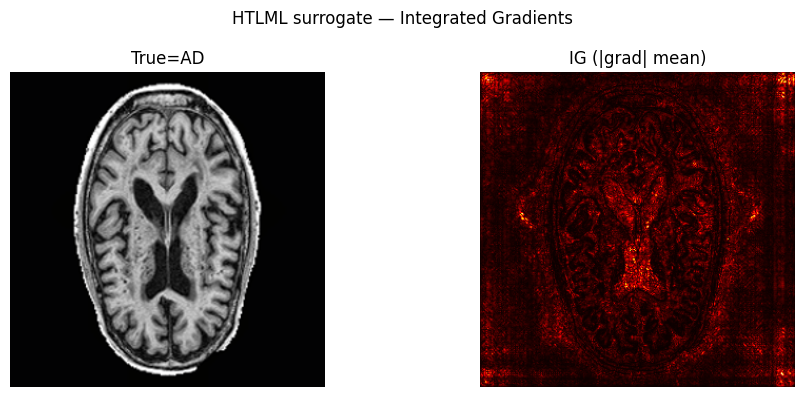

In [18]:
from captum.attr import IntegratedGradients
images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)
with torch.no_grad():
    pred0 = sur(images).argmax(1)
idx = int((pred0 == labels).nonzero(as_tuple=True)[0][0]) if (pred0 == labels).any() else 0
xb = images[idx : idx + 1].clone().detach().requires_grad_(True)
yl = labels[idx : idx + 1]
ig = IntegratedGradients(lambda z: sur(z))
attr = ig.attribute(xb, target=yl, n_steps=32)
mag = attr.abs().mean(dim=1).squeeze().detach().cpu().numpy()
mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)
mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
std = np.array(IMAGENET_STD).reshape(3, 1, 1)
img_np = images[idx].detach().cpu().numpy()
rgb = np.clip(np.transpose(img_np * std + mean, (1, 2, 0)), 0, 1)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(rgb); ax[0].set_title(f'True={CLASS_NAMES[labels[idx]]}'); ax[0].axis('off')
ax[1].imshow(mag, cmap='hot'); ax[1].set_title('IG (|grad| mean)'); ax[1].axis('off')
plt.suptitle('HTLML surrogate — Integrated Gradients')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'ig_htlml_multiclass.png'), dpi=150)
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

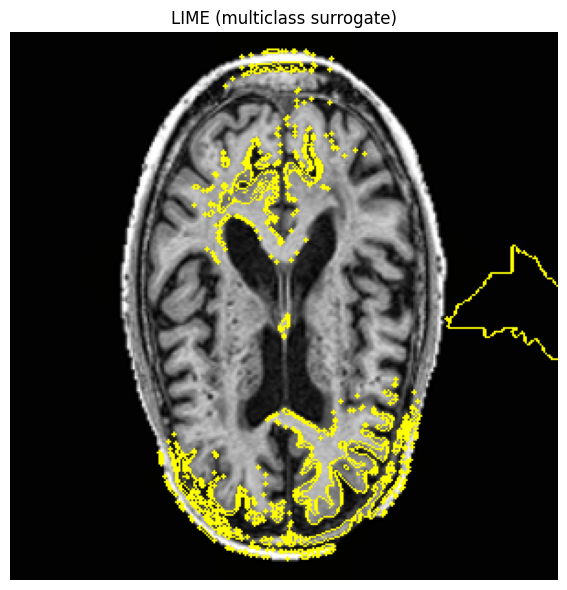

In [19]:
try:
    from lime import lime_image
    from skimage.segmentation import mark_boundaries
    def predict_rgb(rgb_np):
        a = np.asarray(rgb_np, dtype=np.float32)
        if a.ndim == 3:
            a = a[np.newaxis, ...]
        x = torch.from_numpy(a).permute(0, 3, 1, 2).float().to(device) / 255.0
        x = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)(x)
        with torch.no_grad():
            out = sur(x)
        return torch.softmax(out, 1).cpu().numpy()
    rgb255 = (rgb * 255).astype(np.double)
    ex = lime_image.LimeImageExplainer()
    exp = ex.explain_instance(rgb255, predict_rgb, top_labels=len(CLASS_NAMES), hide_color=0, num_samples=LIME_NUM_SAMPLES, batch_size=32)
    temp, mask = exp.get_image_and_mask(exp.top_labels[0], positive_only=True, num_features=10, hide_rest=False)
    plt.figure(figsize=(6, 6))
    plt.imshow(mark_boundaries(temp / 255.0, mask))
    plt.title('LIME (multiclass surrogate)'); plt.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, 'lime_htlml_multiclass.png'), dpi=120)
    plt.show()
except Exception as e:
    print(f'LIME skipped: {e}')

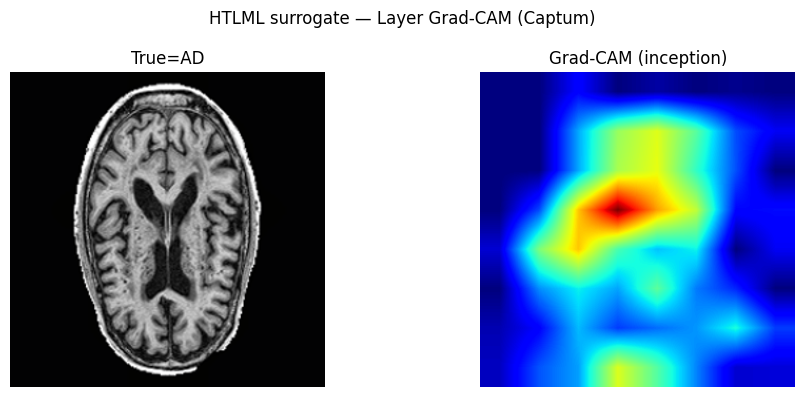

In [20]:
import torch.nn.functional as F
from captum.attr import LayerGradCam

sur.eval()
cam_layer = sur.fe.vgg_features[28] if GRADCAM_BRANCH == 'vgg' else sur.fe.inception.Mixed_7c

images_gc, labels_gc = next(iter(test_loader))
images_gc = images_gc.to(device)
labels_gc = labels_gc.to(device)
with torch.no_grad():
    pred_gc = sur(images_gc).argmax(1)
idx_gc = int((pred_gc == labels_gc).nonzero(as_tuple=True)[0][0]) if (pred_gc == labels_gc).any() else 0

xb_gc = images_gc[idx_gc : idx_gc + 1].clone().detach().requires_grad_(True)
yl_gc = labels_gc[idx_gc : idx_gc + 1]

lgc = LayerGradCam(sur, cam_layer)
cam_attr = lgc.attribute(xb_gc, target=yl_gc)
if isinstance(cam_attr, tuple):
    cam_attr = cam_attr[0]
ca = cam_attr
if ca.dim() == 4:
    cam_map = ca.mean(dim=1, keepdim=True)
elif ca.dim() == 3:
    cam_map = ca.unsqueeze(1)
else:
    cam_map = ca.view(1, 1, ca.shape[-2], ca.shape[-1])
cam_map = F.relu(cam_map.float())
cam_map = F.interpolate(cam_map, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False)
cam_np = cam_map.squeeze().detach().cpu().numpy()
cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-8)

mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
std = np.array(IMAGENET_STD).reshape(3, 1, 1)
img_np = images_gc[idx_gc].detach().cpu().numpy()
rgb_gc = np.clip(np.transpose(img_np * std + mean, (1, 2, 0)), 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(rgb_gc)
ax[0].set_title(f'True={CLASS_NAMES[labels_gc[idx_gc]]}')
ax[0].axis('off')
ax[1].imshow(cam_np, cmap='jet')
ax[1].set_title(f'Grad-CAM ({GRADCAM_BRANCH})')
ax[1].axis('off')
plt.suptitle('HTLML surrogate — Layer Grad-CAM (Captum)')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, 'gradcam_htlml_multiclass.png'), dpi=150)
plt.show()

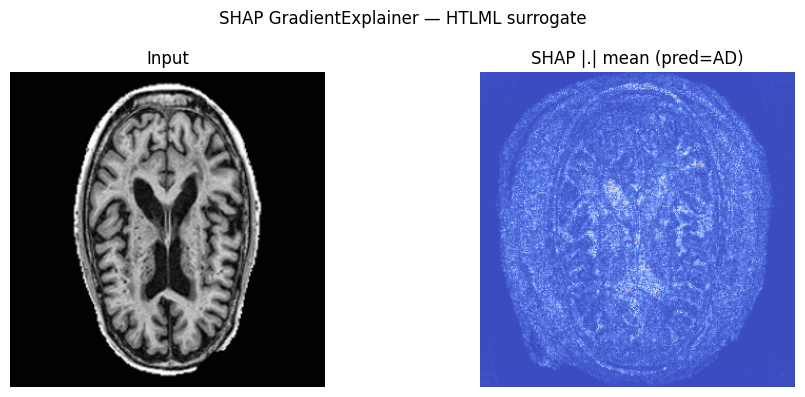

In [21]:
import shap

sur.eval()
bg_list, n_bg = [], 0
for xb, _ in train_loader:
    bg_list.append(xb)
    n_bg += xb.size(0)
    if n_bg >= SHAP_BG_SAMPLES:
        break
background = torch.cat(bg_list, 0)[:SHAP_BG_SAMPLES].to(device)

images_sv, _ = next(iter(test_loader))
images_sv = images_sv.to(device)
xt = images_sv[:1]

mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
std = np.array(IMAGENET_STD).reshape(3, 1, 1)
img0 = images_sv[0].detach().cpu().numpy()
rgb_sv = np.clip(np.transpose(img0 * std + mean, (1, 2, 0)), 0, 1)

try:
    explainer = shap.GradientExplainer(sur, background)
    sv = explainer.shap_values(xt)
    pred_cls = int(sur(xt).argmax(1).item())
    if isinstance(sv, list):
        smap = np.asarray(sv[pred_cls][0])
    else:
        smap = np.asarray(sv[0, :, :, :, pred_cls]) if sv.ndim == 5 else np.asarray(sv[0])
    imp = np.abs(smap).mean(axis=0)
    imp = (imp - imp.min()) / (imp.max() - imp.min() + 1e-8)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(rgb_sv)
    ax[0].set_title('Input')
    ax[0].axis('off')
    ax[1].imshow(imp, cmap='coolwarm')
    ax[1].set_title(f'SHAP |.| mean (pred={CLASS_NAMES[pred_cls]})')
    ax[1].axis('off')
    plt.suptitle('SHAP GradientExplainer — HTLML surrogate')
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, 'shap_htlml_multiclass.png'), dpi=150)
    plt.show()
except Exception as e:
    print(f'SHAP skipped: {e}')

In [22]:
res = {
    'paper': 'Sharma HTLML Diagnostics 2022 10.3390/diagnostics12081833',
    'protocol': 'Phase2-style 80/10/10 slice split + InceptionV3+VGG16 + multiclass VotingClassifier + torch head XAI',
    'class_names': CLASS_NAMES,
    'preprocess_mode': PREPROCESS_MODE,
    'eval_mode': EVAL_MODE,
    'use_pca': USE_PCA,
    'test_log_loss': float(log_loss(y_test, test_prob, labels=list(range(len(CLASS_NAMES))))) if len(y_test) else None,
    'test_slice_acc': float(np.mean(pred_test == y_test)) if len(y_test) else None,
    'per_class_test_f1': {CLASS_NAMES[i]: float(f1[i]) for i in range(len(CLASS_NAMES))},
    'confusion_matrix': cm.tolist(),
}
with open(os.path.join(CKPT_DIR, 'results_htlml_multiclass.json'), 'w', encoding='utf-8') as f:
    json.dump(res, f, indent=2)
print('Wrote results_htlml_multiclass.json')

Wrote results_htlml_multiclass.json


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


In [23]:
csv_path = os.path.join(CKPT_DIR, 'results_htlml_multiclass.csv')
with open(csv_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['metric', 'value'])
    w.writerow(['test_slice_acc', round(res['test_slice_acc'] or 0, 4)])
    w.writerow(['test_log_loss', round(res['test_log_loss'] or 0, 4)])
print(f'Saved {csv_path}')

Saved /kaggle/working/checkpoints_htlml_multiclass/results_htlml_multiclass.csv
